In [ ]:
import sys
sys.path.append('..')

In [ ]:
import numpy as np
from math import log
from tqdm import tqdm
 
from algorithms.Welch_non_adaptative import WelschAlgo as WelschAlgoNonAdaptative
from algorithms.Huber import HuberAlgo
from algorithms.help_functions import generate_linear_model, grid_search_cv_tukey,grid_search_cv_hampel
import statsmodels.api as sm
from statsmodels.robust.norms import TukeyBiweight
from sklearn.model_selection import KFold, train_test_split
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import Hampel
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Break Down point

## General Setup for the break down point experiments

In [ ]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1_000
OUTLIER_SCALE =10000000
DELTA = 0.01
NUM_REPETITIONS = 5_000
EPSILON_RANGE = np.arange(0.0, 0.11, 0.01)
MAX_ITER = 100
SEED = 100
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES

## Experminets

### Welsch

In [ ]:
break_down_Welsch= []
 
for epsilon in EPSILON_RANGE:
    tau = tau_base + epsilon
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = WelschAlgoNonAdaptative(X, y)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_Welsch.append((epsilon, bias))

### Huber

In [ ]:
break_down_huber = []
 
for epsilon in EPSILON_RANGE:
    squared_errors = []
    beta_hats = []
    
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        gamma = np.sqrt(P_FEATURES/N_SAMPLES)+epsilon
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_huber.append((epsilon, bias))


### Tukey’s biweight

In [ ]:
break_down_tukey = []
c_values=np.linspace(3, 6, 4)
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Tukey constant on validation set
        best_c = grid_search_cv_tukey(
            X_val, y_val, c_values,
            n_splits=5
        )
 
        # Refit on training set with best parameters
        rlm_model = sm.RLM(y_train, X_train, M=TukeyBiweight(c=best_c))
        beta_hat = rlm_model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_tukey.append((epsilon, bias))
 

### Hampel’s three-part

In [ ]:
break_down_hampel = []
A_VALUES = [1.5, 2.0,4.0]
B_VALUES = [3.0, 4.0, 5.0]
C_VALUES = [6.0, 8.0, 10.0]
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Hampel constants on validation set
        best_params = grid_search_cv_hampel(
            X_val, y_val, A_VALUES, B_VALUES, C_VALUES,
            n_splits=5, random_state=rep,
        )
 
        # Refit on training set with best parameters
        model = RLM(y_train, X_train, M=Hampel(**best_params))
        beta_hat = model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_hampel.append((epsilon, bias))

### Quantile Regression

In [ ]:
break_down_quantile_1 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.1).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_1.append((epsilon, bias))

In [ ]:
break_down_quantile_5 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.5).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_5.append((epsilon, bias))

In [ ]:
break_down_quantile_9 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.9).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_9.append((epsilon, bias))

## Plots

Since the above experiments take long time we provide the results we got in the folder results_break_down_points

### Downloading Data

In [198]:
break_Welsch= pd.read_csv('../Data/break_down_points/break_down_exp_Welsch.csv')

In [199]:
break_down_huber=pd.read_csv('../Data/break_down_points/break_down_exp_Hube.csv')

In [200]:
break_down_tukey=pd.read_csv('../Data/break_down_points/break_down_exp_tukey.csv', sep=';')

In [201]:
break_down_hampel=pd.read_csv('../Data/break_down_points/break_down_exp_Hampel.csv',sep=';')

In [202]:
break_down_quantile_1=pd.read_csv('../Data/break_down_points/break_down_exp_quantile_reg_q_1.csv')

In [203]:
break_down_quantile_5=pd.read_csv('../Data/break_down_points/break_down_exp_quantile_regression_q_5.csv')

In [204]:
break_down_quantile_9=pd.read_csv('../Data/break_down_points/break_down_exp_quantile_regression_q_9.csv')

### Turning Data to data frames 

In [205]:
break_down_Welsch_df = pd.DataFrame(break_Welsch, columns=['delta', 'Error'])

In [206]:
break_down_huber_df = pd.DataFrame(break_down_huber,columns=['delta', 'Error'])

In [207]:
break_down_tukey_df = pd.DataFrame(break_down_tukey, columns=['delta', 'Error'])

In [208]:
break_down_hampel_df = pd.DataFrame(break_down_hampel, columns=['delta', 'Error'])

In [209]:
break_down_quantile_1_df = pd.DataFrame(break_down_quantile_1, columns=['delta', 'Error'])

In [210]:
break_down_quantile_5_df = pd.DataFrame(break_down_quantile_5, columns=['delta', 'Error'])

In [211]:
break_down_quantile_9_df = pd.DataFrame(break_down_quantile_9, columns=['delta', 'Error'])

### Comparison of the Euclidean norm of the bias of the Welsch estimator against other robust estimators.

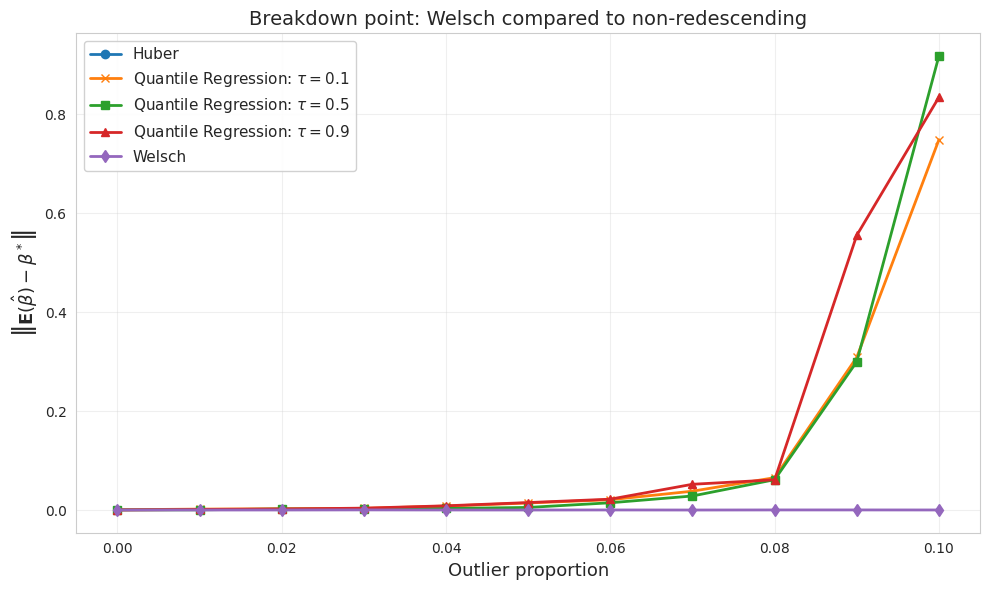

In [212]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_huber_df['delta'], break_down_huber_df['Error'],
         label='Huber', marker='o', linewidth=2)
plt.plot(break_down_quantile_1_df['delta'], break_down_quantile_1_df['Error'],
         label=r'Quantile Regression: $\tau=0.1$', marker='x', linewidth=2)
plt.plot(break_down_quantile_5_df['delta'], break_down_quantile_5_df['Error'],
         label=r'Quantile Regression: $\tau=0.5$', marker='s', linewidth=2)
plt.plot(break_down_quantile_9_df['delta'], break_down_quantile_9_df['Error'],
         label=r'Quantile Regression: $\tau=0.9$', marker='^', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to non-redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

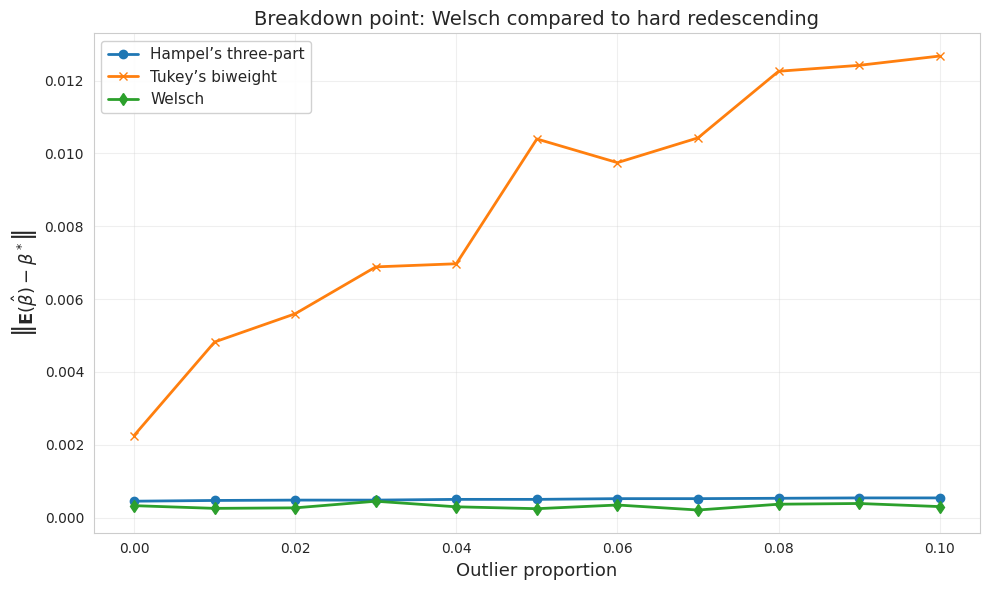

In [213]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_hampel_df['delta'], break_down_hampel_df['Error'],
         label='Hampel’s three-part', marker='o', linewidth=2)
plt.plot(break_down_tukey_df['delta'], break_down_tukey_df['Error'],
         label='Tukey’s biweight', marker='x', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to hard redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mean Square Error

### Huber VS Welsch

#### General Setup

In [ ]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1000
OUTLIER_SCALE =1000000
DELTA = 0.01
NUM_REPETITIONS = 1000
MAX_ITER = 100
SEED = 100
NUM_BATCH_MSE_ESTIMATION=1000
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES
per_outliers=0.1


#### Welsch

In [ ]:
MSE_Welsch=[]
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Welsch:"):
    SE_Welsch=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Welsch:"):
            seed=exp*rep
            tau = (tau_base + per_outliers)
            y,X,_ = generate_linear_model(
                N_SAMPLES,
                P_FEATURES,
                beta_star,
                seed=seed,
                outliers=True,
                outlier_const=OUTLIER_SCALE,
                noise_type="pareto",
                outliers_perc=per_outliers,
            )
    
            model = WelschAlgoNonAdaptative(X, y)
            beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
            SE_Welsch.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Welsch.append(np.mean(SE_Welsch))

#### Huber

In [ ]:
MSE_Huber= []
 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Huber:"):
    SE_Huber=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Huber:"):
        seed=exp*rep
        gamma =np.sqrt(P_FEATURES/N_SAMPLES)+per_outliers
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=1000)
 
        SE_Huber.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Huber.append(np.mean(SE_Huber))

#### Distribution of the MSE of Huber and Welsch estimators under corruption

Since the above experiments take long time we provide the results we got in the folder results_break_down_points

##### Downloading Data

In [214]:
MSE_Huber_Welsch = pd.read_csv("../Data/MSE/histogram_data_Huber_Welsch.csv")
 
welsch = MSE_Huber_Welsch[MSE_Huber_Welsch["Estimator"] == "Welsch"]
huber = MSE_Huber_Welsch[MSE_Huber_Welsch["Estimator"] == "Huber"]

##### Histogram

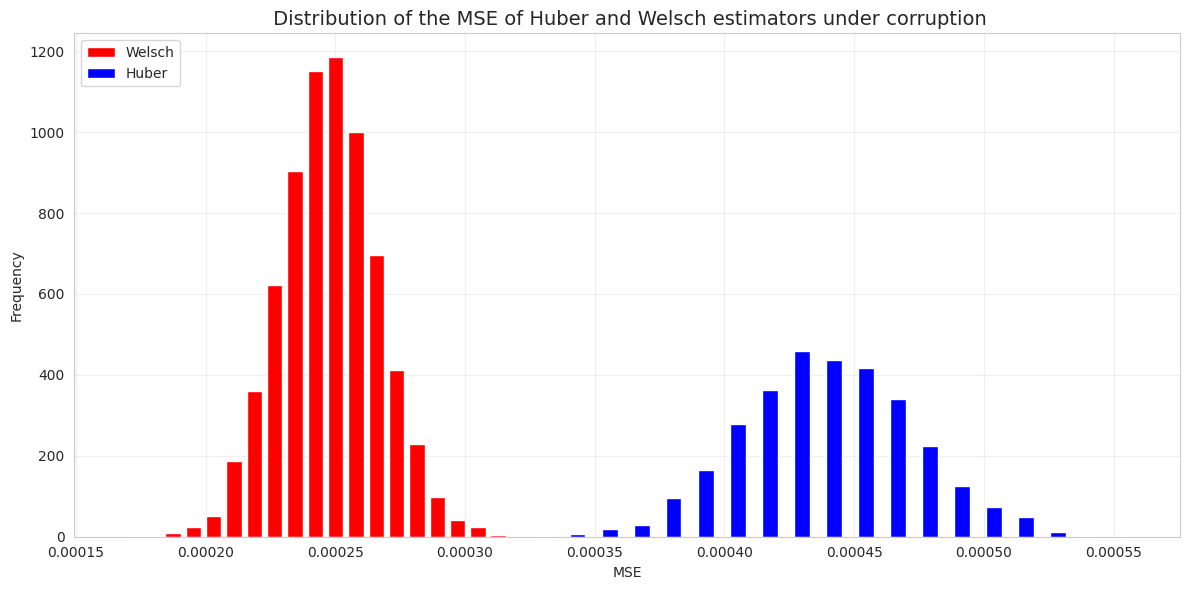

In [215]:
fig, ax = plt.subplots(figsize=(12, 6))
 
bar_width = 0.000006
 
ax.bar(welsch["MSE"], welsch["Frequency"], width=bar_width, color="red", label="Welsch")
ax.bar(huber["MSE"], huber["Frequency"], width=bar_width, color="blue", label="Huber")
 
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.title(' Distribution of the MSE of Huber and Welsch estimators under corruption', fontsize=14)
plt.tight_layout()
plt.show()

### Welsch VS Redecenders

#### General Setup

In [ ]:
N_SAMPLES = 10000
P_FEATURES = 10
BETA_SCALE = 1000
OUTLIER_SCALE =10000000
DELTA = 0.01
NUM_REPETITIONS = 1000
MAX_ITER = 100
SEED = 100
NUM_BATCH_MSE_ESTIMATION=1000
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES
per_outliers=0.2

#### Welsch

In [ ]:
MSE_Welsch_Redecenders=[]
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Welsch:"):
    SE_Welsch=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Welsch:"):
        seed=exp*(rep+1)
        tau = tau_base + per_outliers
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        model = WelschAlgoNonAdaptative(X_train, y_train)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        SE_Welsch.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    
    MSE_Welsch_Redecenders.append(np.mean(SE_Welsch))


#### Tukey’s biweight

In [ ]:
MSE_Tukey = []
c_values=np.linspace(3, 6, 4)
 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Tukey:"):
    SE_Tukey=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Tukey:"):
        seed=exp*rep
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        # Tune Tukey constant on validation set
        best_c = grid_search_cv_tukey(
            X_val, y_val, c_values,
            n_splits=5
        )
 
        # Refit on training set with best parameters
        rlm_model = sm.RLM(y_train, X_train, M=TukeyBiweight(c=best_c))
        beta_hat = rlm_model.fit().params
        SE_Tukey.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    
    MSE_Tukey.append(np.mean(SE_Tukey))

#### Hampel’s three-part

In [ ]:
MSE_Hampel = []
A_VALUES = [1.5, 2.0,4.0]
B_VALUES = [3.0, 4.0, 5.0]
C_VALUES = [6.0, 8.0, 10.0]
 

 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Hampel:"):
    SE_Hampel=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Hampel:"):
        seed=exp*rep
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        # Tune Hampel constants on validation set
        best_params = grid_search_cv_hampel(
            X_val, y_val, A_VALUES, B_VALUES, C_VALUES,
            n_splits=5, random_state=seed,
        )
 
        # Refit on training set with best parameters
        model = RLM(y_train, X_train, M=Hampel(**best_params))
        beta_hat = model.fit().params
 
        SE_Hampel.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Hampel.append(np.mean(SE_Hampel))

#### Distribution of the MSE of redescending estimators under heavy corruption.

##### Downloading Data

In [216]:
KDE_redecenders = pd.read_csv("../Data/MSE/kde_Welsch_Hampel_Tukey.csv")

##### Histogram

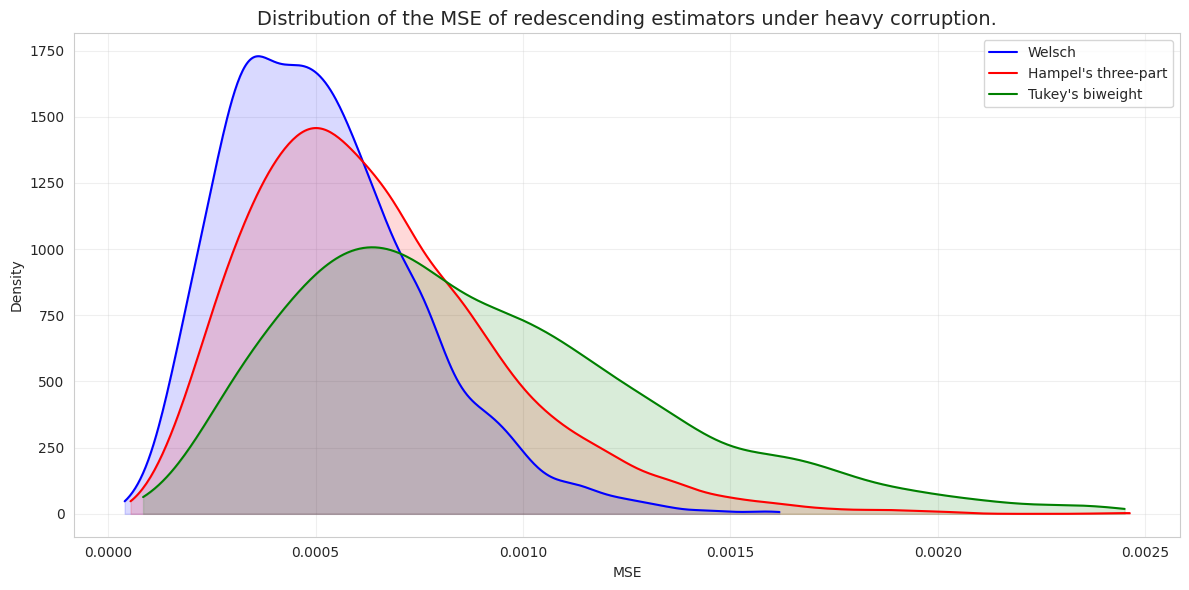

In [217]:
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = {"Welsch": "blue", "Hampel's three-part": "red", "Tukey's biweight": "green"}
 
for series, color in colors.items():
    subset = KDE_redecenders[KDE_redecenders["Estimators"] == series]
    ax.plot(subset["x"], subset["density"], color=color, label=series, linewidth=1.5)
    ax.fill_between(subset["x"], subset["density"], alpha=0.15, color=color)
 
ax.set_xlabel("MSE")
ax.set_ylabel("Density")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.title('Distribution of the MSE of redescending estimators under heavy corruption.', fontsize=14)
plt.tight_layout()
plt.show()